# Tratamento dos dados

Dado que uma rede MLP espera como entrada um vetor unidimensional de características, é necessário adequar a representação das imagens da base de dados para esse formato.

Para isso, aplicaram-se as seguintes etapas de pré-processamento:

1. Conversão das imagens de RGB para escala de cinza, removendo os canais de cor e mantendo apenas a intensidade dos pixels, o que reduz a dimensionalidade dos dados.

2. *Flatten* das imagens para representação em linha, transformando a matriz bidimensional da imagem em um vetor unidimensional de características.

In [13]:
# Imports

from keras.datasets import cifar10
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import set_random_seed, to_categorical
from keras.optimizers import Adam

set_random_seed(42)

In [14]:
# Carregamento dos dados

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print('Train Images Shape:      ', x_train.shape)
print('Train Labels Shape:      ', y_train.shape)

print('\nTest Images Shape:       ', x_test.shape)
print('Test Labels Shape:       ', y_test.shape)

Train Images Shape:       (50000, 32, 32, 3)
Train Labels Shape:       (50000, 1)

Test Images Shape:        (10000, 32, 32, 3)
Test Labels Shape:        (10000, 1)


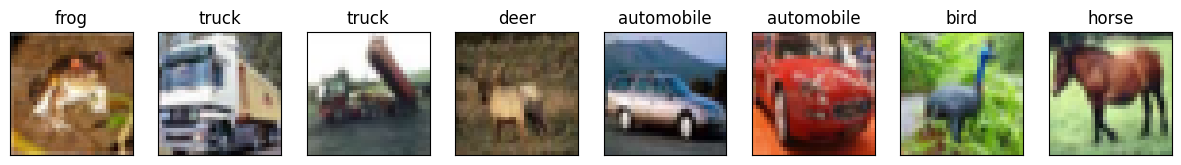

In [15]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 8 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train[i])

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [16]:
# Conversão das imagens de RGB para escala de cinza

# fórmula padrão: Y = 0.299 R + 0.587 G + 0.114 B
x_train_gray = np.dot(x_train[..., :3], [0.299, 0.587, 0.114])
x_test_gray = np.dot(x_test[..., :3], [0.299, 0.587, 0.114])

print('Train Images Shape (Gray scale):      ', x_train_gray.shape)
print('Test Images Shape (Gray scale):       ', x_test_gray.shape)

Train Images Shape (Gray scale):       (50000, 32, 32)
Test Images Shape (Gray scale):        (10000, 32, 32)


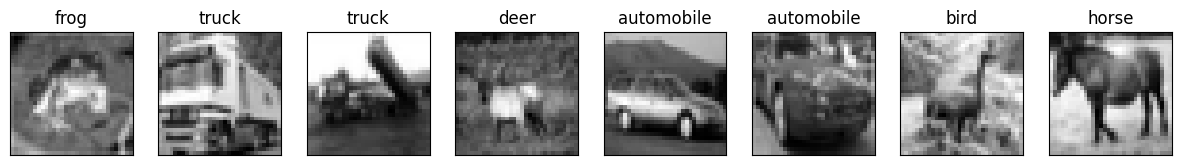

In [17]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 8 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train_gray[i], cmap='gray')

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [18]:
# Flatten das imagens e normalização [0, 1] (melhora estabilidade e acurácia)

x_train_flat = x_train_gray.reshape(x_train_gray.shape[0], -1).astype('float32') / 255.0
x_test_flat = x_test_gray.reshape(x_test_gray.shape[0], -1).astype('float32') / 255.0

x_train_df = pd.DataFrame(x_train_flat)
x_test_df = pd.DataFrame(x_test_flat)

print('Train Images Shape (Gray scale & Flatten):      ', x_train_df.shape)
print('Test Images Shape (Gray scale & Flatten):       ', x_test_df.shape)

# Conversão dos rótulos para one-hot encoding

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

Train Images Shape (Gray scale & Flatten):       (50000, 1024)
Test Images Shape (Gray scale & Flatten):        (10000, 1024)


# Estrutura da rede

In [19]:
# Hiper-parâmetros

input_shape = 1024                  # 32 x 32 x 1
epochs = 50                         # https://keras.io/examples/vision/mlp_image_classification/
batch_size = 128                    # https://wandb.ai/sulbing/CIFAR10/reports/CIFAR10-Only-MLP-Not-CNN---Vmlldzo1NjkyNjMw
dropout_rate = 0.2                  # https://keras.io/examples/vision/mlp_image_classification/
learning_rate = 0.001               # https://wandb.ai/sulbing/CIFAR10/reports/CIFAR10-Only-MLP-Not-CNN---Vmlldzo1NjkyNjMw

#Outras Fontes
#https://pvss.github.io/MLP+of+CIFAR-10
#https://www.kaggle.com/code/yorkyong/exploring-cifar-10-w-mlp-cnn-resnet

In [20]:
# Construção do modelo MLP

def create_model_1():

    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_shape,)),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    return model

# Experimento 1 - Sem dropout e sem early stop

In [ ]:
histories = []
train_accuracies = []
test_losses = []
test_accuracies = []

for i in range(3):

    print(f'Execução {i+1}')

    model_1 = create_model_1()

    history = model_1.fit(
        x_train_df.values,
        y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=0,
    )

    histories.append(history)

    train_acc = history.history['accuracy'][-1] 
    train_accuracies.append(train_acc)          

    loss, acc = model_1.evaluate(
        x_test_df.values,
        y_test_cat,
        verbose=0
    )

    test_losses.append(loss)
    test_accuracies.append(acc)

    print(f'Execução {i+1} | Treino — acurácia: {train_acc:.4f} | Teste — loss: {loss:.4f}, acurácia: {acc:.4f}')

Execução 1
Execução 1 | Teste — loss: 1.9571, acurácia: 0.3971
Execução 2
Execução 2 | Teste — loss: 1.9067, acurácia: 0.4002
Execução 3
Execução 3 | Teste — loss: 1.8776, acurácia: 0.3929


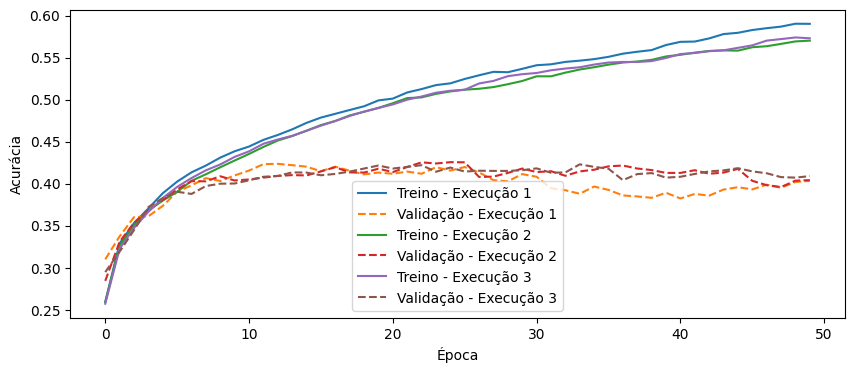

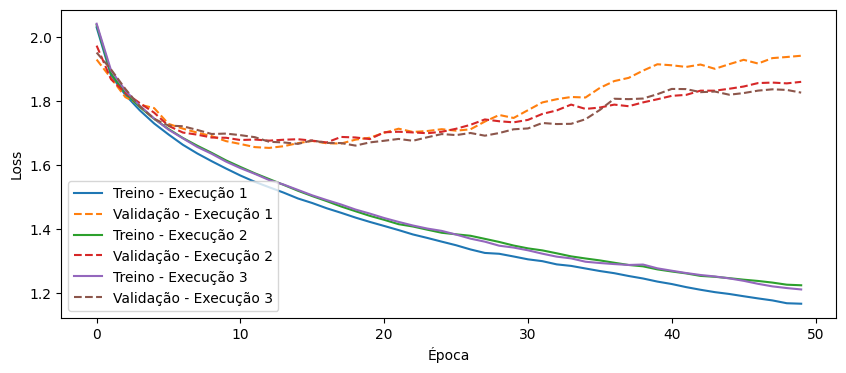

Execução 1:
Loss: 1.9571
Acurácia: 0.3971
Execução 2:
Loss: 1.9067
Acurácia: 0.4002
Execução 3:
Loss: 1.8776
Acurácia: 0.3929


In [ ]:
# Acurácia de validação e teste

plt.figure(figsize=(10,4))

for i, history in enumerate(histories):
    plt.plot(history.history['accuracy'], label=f'Treino - Execução {i+1}')
    plt.plot(history.history['val_accuracy'], '--', label=f'Validação - Execução {i+1}')

plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

# Perda de validação e teste

plt.figure(figsize=(10,4))

for i, history in enumerate(histories):
    plt.plot(history.history['loss'], label=f'Treino - Execução {i+1}')
    plt.plot(history.history['val_loss'], '--', label=f'Validação - Execução {i+1}')

plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Resultado do experimento
for i in range(3):
    print(f'Execução {i+1}:')
    print(f'  Treino — acurácia: {train_accuracies[i]:.4f}')
    print(f'  Teste  — loss: {test_losses[i]:.4f}, acurácia: {test_accuracies[i]:.4f}')

# Experimento 2 - Sem dropout e com early stop

In [27]:
# Treinamento

In [28]:
# Resutados

# Experimento 3 - Com dropout e sem early stop

In [29]:
# Treinamento

In [30]:
# Resultados

# Experimento 4 - Com dropout e com early stop

In [31]:
# Treinamento

In [32]:
# Resultados